# 3.1 — Основные метрики и калибровка

**Папка 3 «Оценка», подноутбук 1.** Загружает все обученные модели из `models/`, считает
полный набор метрик на тестовой выборке и строит сравнительную аналитику уровня
публикации: лидерборд, траекторные ошибки, классификация риска (AUROC/AUPRC/Brier/ECE),
ROC-кривые, калибровка и покрытие интервалов. Все рисунки и таблицы — на английском.

## Окружение, данные и модели

In [2]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table
from liquefaction_ai.models import CatBoostBaseline

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from liquefaction_ai.viz import bar, calibration_plot, grouped_bar, lines

models, predictions, sample_tables, rows = {}, {}, {}, []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name)
    disp = hp["display_name"]
    out = collect_outputs(model, test, config, device)
    met, sample_df = compute_metrics(disp, out, test, config)
    models[disp] = model; predictions[disp] = out; sample_tables[disp] = sample_df; rows.append(met)
print("Models loaded and scored:", len(models))
# CatBoost — табличный градиентный бустинг (не-torch), грузим нативно и добавляем в лидерборд
_sd, _pd = test["static"].shape[1], test["prefix_summary"].shape[1]
_cb = CatBoostBaseline(_sd, _pd).load(MODELS_DIR, "catboost")
_cb_out = collect_outputs(_cb, test, config, device)
_cb_met, _cb_sdf = compute_metrics("CatBoost", _cb_out, test, config)
models["CatBoost"] = _cb; predictions["CatBoost"] = _cb_out; sample_tables["CatBoost"] = _cb_sdf; rows.append(_cb_met)
print("CatBoost added | total models:", len(models))

Models loaded and scored: 13
CatBoost added | total models: 14


## Leaderboard

In [3]:
leaderboard = pd.DataFrame(rows).sort_values(["Traj_RMSE", "Brier"], na_position="last").reset_index(drop=True)
display(english_metric_table(leaderboard).round(4))
leaderboard.to_csv(REPO_ROOT / "results" / "tables" / "full_leaderboard.csv", index=False)
print("saved results/tables/full_leaderboard.csv")

# === Раздельные лидерборды (честность сравнения) ===
# Risk-only модели (CatBoost, FT-Transformer, MLP-Risk) не выдают траекторию/CRR — их сведение
# в один лидерборд с физическими моделями вводит в заблуждение. Делим на два:
#   • leaderboard_risk.csv        — все модели, только метрики риска/события;
#   • leaderboard_trajectory.csv  — только state-space/physics модели (есть траектория PPR).
leaderboard["Produces_Trajectory"] = leaderboard["Traj_RMSE"].notna().astype(int)
_tab = REPO_ROOT / "results" / "tables"
_risk_cols = ["model", "AUROC", "AUPRC", "Brier", "ECE",
              "N_liq_logMAE", "N_liq_MAE", "N_liq_n_observed", "Produces_Trajectory"]
risk_lb = (leaderboard[[c for c in _risk_cols if c in leaderboard.columns]]
           .sort_values("AUROC", ascending=False).reset_index(drop=True))
risk_lb.to_csv(_tab / "leaderboard_risk.csv", index=False)
_traj_cols = ["model", "Traj_RMSE", "Traj_CRPS", "Calibration_Error", "Coverage_90",
              "Physics_Violation_Rate", "CRR_RMSE", "N_CRR_test", "N_CRR_objects",
              "N_liq_logMAE", "N_liq_n_observed"]
traj_lb = (leaderboard[leaderboard["Produces_Trajectory"] == 1][[c for c in _traj_cols if c in leaderboard.columns]]
           .sort_values("Traj_RMSE").reset_index(drop=True))
traj_lb.to_csv(_tab / "leaderboard_trajectory.csv", index=False)
print(f"saved leaderboard_risk.csv ({len(risk_lb)} моделей) и leaderboard_trajectory.csv ({len(traj_lb)} моделей)")
print(f"CRR-метрика опирается на N_CRR_test={int(leaderboard['N_CRR_test'].dropna().max() or 0)} образцов "
      f"из N_CRR_objects={int(leaderboard['N_CRR_objects'].dropna().max() or 0)} объектов — малая выборка.")

,Model,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,ECE,...,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR,Trajectory RMSE (liquefied),"Trajectory RMSE (no-liq, stabilized)","Trajectory RMSE (no-liq, not stabilized)",Trajectory RMSE (balanced over states),Trajectory RMSE (worst state)
0,DPI-EVT,42.2032,90.3597,0.2221,0.3791,168,0.9991,0.9992,0.0128,0.0219,...,0.0453,0.1574,71,1,True,0.1149,0.0772,NaN,0.0961,0.1149
1,EVT-NeuralSSM,54.9602,191.8728,0.2355,0.4112,168,0.9986,0.9987,0.0169,0.0308,...,0.0590,0.2107,71,1,True,0.1487,0.0792,NaN,0.1140,0.1487
2,DPI-Flow,168.7823,553.4623,0.2284,0.4077,168,0.9986,0.9987,0.0216,0.0423,...,0.0703,0.2085,71,1,True,0.1437,0.1238,NaN,0.1338,0.1437
3,Transformer,1337.4240,1856.8458,1.4656,1.7007,168,1.0000,1.0000,0.0523,0.1879,...,0.0984,NaN,0,0,False,0.1401,0.2107,NaN,0.1754,0.2107
4,GRU,1315.5884,1652.5100,1.6193,1.8728,168,0.9940,0.9954,0.2075,0.4301,...,0.1426,NaN,0,0,False,0.1705,0.3074,NaN,0.2390,0.3074
5,RealNVP,1449.9598,1983.5413,2.0363,2.2914,168,0.9787,0.9823,0.1405,0.2549,...,0.1509,NaN,0,0,False,0.3212,0.1994,NaN,0.2603,0.3212
6,PINN,1188.7037,1632.6873,1.2386,1.4168,168,0.9933,0.9946,0.1348,0.3328,...,0.1698,NaN,0,0,False,0.1800,0.3603,NaN,0.2702,0.3603
7,Neural Spline Flow,1384.8853,1898.5237,1.7675,1.9851,168,0.9845,0.9864,0.1380,0.2650,...,0.1780,NaN,0,0,False,0.3712,0.2120,NaN,0.2916,0.3712
8,TCN,1469.1125,2015.4249,2.1422,2.4452,168,0.9714,0.9839,0.2179,0.1835,...,0.1750,NaN,0,0,False,0.2950,0.3031,NaN,0.2991,0.3031
9,LSTM,1497.8059,2047.7229,2.4384,2.7762,168,0.9187,0.9572,0.2527,0.3728,...,0.1785,NaN,0,0,False,0.3022,0.2998,NaN,0.3010,0.3022


saved results/tables/full_leaderboard.csv
saved leaderboard_risk.csv (14 моделей) и leaderboard_trajectory.csv (11 моделей)
CRR-метрика опирается на N_CRR_test=71 образцов из N_CRR_objects=1 объектов — малая выборка.


In [4]:
# === Главная сравнительная таблица ===
# N_liq error | PPR curve error | Calibration | Physics violations
import os
main_cols = {
    "model": "Model",
    "N_liq_MAE": "N_liq MAE (cyc)", "N_liq_logMAE": "N_liq log-MAE",
    "Traj_RMSE": "PPR curve RMSE",
    "Coverage_90": "Coverage@90%", "ECE": "ECE (calib.)",
    "Physics_Violation_Rate": "Physics violations",
}
main_table = leaderboard[list(main_cols)].rename(columns=main_cols)
display(main_table.round(4))
os.makedirs(REPO_ROOT / "results" / "tables", exist_ok=True)
main_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "main_comparison.csv", index=False)
print("saved results/tables/main_comparison.csv")

,Model,N_liq MAE (cyc),N_liq log-MAE,PPR curve RMSE,Coverage@90%,ECE (calib.),Physics violations
0,DPI-EVT,42.2032,0.2221,0.0963,0.9401,0.0219,0.0000
1,EVT-NeuralSSM,54.9602,0.2355,0.1163,0.9605,0.0308,0.0000
2,DPI-Flow,168.7823,0.2284,0.1333,0.9522,0.0423,0.0000
3,Transformer,1337.4240,1.4656,0.1818,0.9573,0.1879,0.0000
4,GRU,1315.5884,1.6193,0.2542,0.8457,0.4301,0.1548
5,RealNVP,1449.9598,2.0363,0.2622,0.9271,0.2549,0.9940
6,PINN,1188.7037,1.2386,0.2921,0.7803,0.3328,0.0000
7,Neural Spline Flow,1384.8853,1.7675,0.2956,0.7172,0.2650,1.0000
8,TCN,1469.1125,2.1422,0.2994,0.9980,0.1835,0.0000
9,LSTM,1497.8059,2.4384,0.3009,0.9468,0.3728,0.0000


saved results/tables/main_comparison.csv


## Probabilistic & physics quality — structured models

Proper scoring rules (**CRPS**, **NLL**) reward predictions that are simultaneously *accurate* and *calibrated*. DPI-Flow, EVT-NeuralSSM and DPI-EVT emit a physical CRR(N) resistance curve. The current grouped leaderboard below is the source of truth for which model leads each metric; this section highlights that the structured models combine calibrated uncertainty, zero monotonicity violations and CRR capability, while black-box flows/RNNs routinely violate monotonicity.


In [5]:
# Таблица вероятностного и физического качества
prob_cols = {"model": "Model", "Traj_CRPS": "CRPS ↓", "Traj_NLL": "NLL ↓",
             "Calibration_Error": "Calib. err ↓", "Coverage_90": "Cov@90%",
             "Physics_Violation_Rate": "Physics viol. ↓", "CRR_RMSE": "CRR RMSE ↓"}
prob_table = leaderboard[list(prob_cols)].rename(columns=prob_cols)
display(prob_table.round(4))
prob_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "probabilistic_quality.csv", index=False)
print("saved results/tables/probabilistic_quality.csv")

,Model,CRPS ↓,NLL ↓,Calib. err ↓,Cov@90%,Physics viol. ↓,CRR RMSE ↓
0,DPI-EVT,0.0453,-1.2408,0.0435,0.9401,0.0000,0.1574
1,EVT-NeuralSSM,0.0590,-0.8241,0.0686,0.9605,0.0000,0.2107
2,DPI-Flow,0.0703,-0.6907,0.0366,0.9522,0.0000,0.2085
3,Transformer,0.0984,-0.3861,0.0492,0.9573,0.0000,NaN
4,GRU,0.1426,0.0101,0.0477,0.8457,0.1548,NaN
5,RealNVP,0.1509,0.0406,0.0453,0.9271,0.9940,NaN
6,PINN,0.1698,0.2773,0.1159,0.7803,0.0000,NaN
7,Neural Spline Flow,0.1780,0.2987,0.1694,0.7172,1.0000,NaN
8,TCN,0.1750,0.2628,0.1011,0.9980,0.0000,NaN
9,LSTM,0.1785,0.2706,0.0536,0.9468,0.0000,NaN


saved results/tables/probabilistic_quality.csv


In [6]:
# Матрица возможностей: что вообще умеет каждая модель
PHYS_MODELS = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT"}
lb_idx = leaderboard.set_index("model")
cap = []
for disp, out in predictions.items():
    viol = float(lb_idx.loc[disp, "Physics_Violation_Rate"]) if disp in lb_idx.index else float("nan")
    cap.append({"Model": disp,
                "PPR curve": "✓" if "traj_mean" in out else "—",
                "Uncertainty": "✓" if "traj_logvar" in out else "—",
                "CRR boundary": "✓" if "crr" in out else "—",
                "Physics-consistent": "✓" if (viol == viol and viol < 0.05) else "—"})
capability = pd.DataFrame(cap).set_index("Model")
display(capability)

,PPR curve,Uncertainty,CRR boundary,Physics-consistent
Model,,,,
MLP-Risk,—,—,—,—
GRU,✓,✓,—,—
TCN,✓,✓,—,✓
LSTM,✓,✓,—,✓
Transformer,✓,✓,—,✓
FT-Transformer,—,—,—,—
PINN,✓,✓,—,✓
DeepState,✓,✓,—,✓
RealNVP,✓,✓,—,—


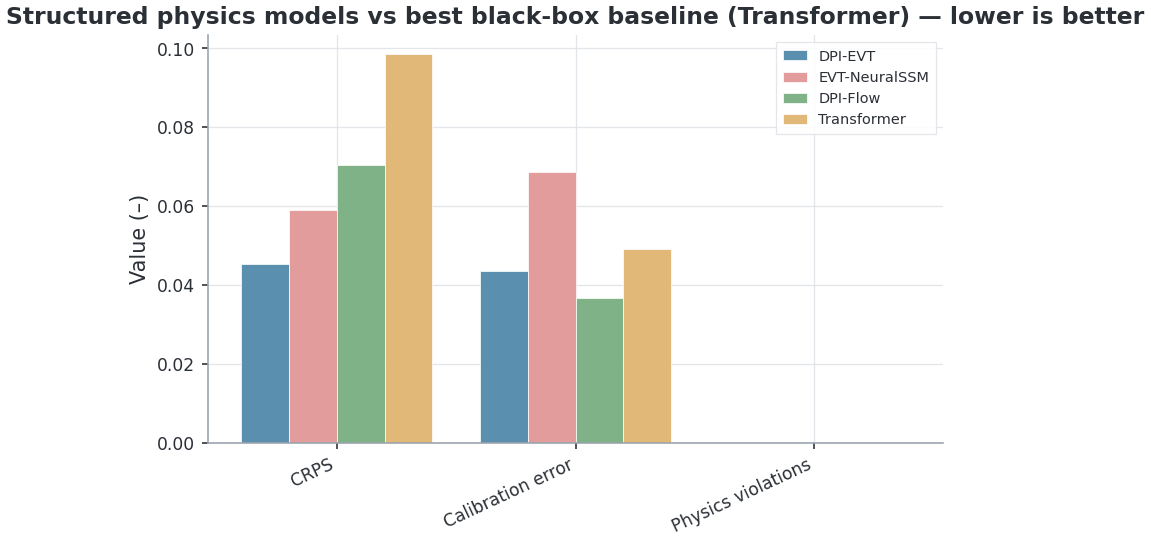

DPI-Flow: CRPS +28.6% vs Transformer | calib.err 0.037 | physics-viol 0.000 | CRR RMSE 0.2085 (baselines: n/a)
EVT-NeuralSSM: CRPS +40.1% vs Transformer | calib.err 0.069 | physics-viol 0.000 | CRR RMSE 0.2107 (baselines: n/a)
DPI-EVT: CRPS +54.0% vs Transformer | calib.err 0.044 | physics-viol 0.000 | CRR RMSE 0.1574 (baselines: n/a)


In [7]:
# Наглядное сравнение структурных моделей с лучшим ЧЁРНЫМ ЯЩИКОМ
PHYS_INFORMED = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT", "PINN"}   # физически-информированные — не baseline
blackbox = leaderboard[~leaderboard["model"].isin(PHYS_INFORMED)].dropna(subset=["Traj_CRPS"])
best_base = blackbox.sort_values("Traj_CRPS").iloc[0]["model"]
sel = leaderboard[leaderboard["model"].isin(list(PHYS_MODELS) + [best_base])].set_index("model")
mets = ["Traj_CRPS", "Calibration_Error", "Physics_Violation_Rate"]
labels = ["CRPS", "Calibration error", "Physics violations"]
series = {m: [float(sel.loc[m, k]) for k in mets] for m in sel.index}
grouped_bar(labels, series,
            title=f"Structured physics models vs best black-box baseline ({best_base}) — lower is better",
            ylabel="Value (–)", save=SAVE_FIGS, fig_id="3_1_structured_advantage").show()
for m in PHYS_MODELS:
    if m in sel.index:
        d = (sel.loc[best_base, "Traj_CRPS"] - sel.loc[m, "Traj_CRPS"]) / sel.loc[best_base, "Traj_CRPS"] * 100
        print(f"{m}: CRPS {d:+.1f}% vs {best_base} | calib.err {sel.loc[m,'Calibration_Error']:.3f} | "
              f"physics-viol {sel.loc[m,'Physics_Violation_Rate']:.3f} | CRR RMSE {sel.loc[m,'CRR_RMSE']:.4f} (baselines: n/a)")

## P³-Score и Pareto-ранжирование (публикационное)

Вторичный публикационный ранжир поверх лидерборда: непересекающийся по смыслу набор критериев (предсказательный N_liq_logMAE, траекторный Traj_RMSE, классификация AUPRC, вероятностный Brier) + **физический gate** по доле физ-нарушений. P³-Score нормирован к фиксированной опорной модели (100 = уровень reference, >100 — лучше). Pareto-фронт — недоминируемая сортировка по тем же критериям.

In [8]:
from liquefaction_ai.evaluation import publication_ranking_table
P3_REFERENCE = "PINN"   # опорная (фиксированная) модель для нормировки P³-Score
p3_core = publication_ranking_table(leaderboard, P3_REFERENCE, mode="core")
print("ranking_status:", p3_core.attrs.get("ranking_status", "ok"))
display(english_metric_table(p3_core).round(3))
p3_core.round(4).to_csv(REPO_ROOT / "results" / "tables" / "p3_core_ranking.csv", index=False)
print("saved results/tables/p3_core_ranking.csv")

ranking_status: ok


,Model,Pareto front (raw),Pareto front (adm.),P³ Core raw,P³ Core admissible,Physically unreliable,Competence gate failed,Competence gate reason,Excluded (adm.),Physical penalty,...,Trajectory RMSE,Brier,AUPRC,MAE N_liq (cycles),RMSE N_liq (cycles),AUROC,ECE,Trajectory MAE,Trajectory MSE,Produces CRR
0,DPI-EVT,1.0,1.0,473.208,473.208,False,False,,False,0.000,...,0.096,0.013,0.999,42.203,90.360,0.999,0.022,0.063,0.009,True
1,EVT-NeuralSSM,2.0,2.0,414.438,414.438,False,False,,False,0.000,...,0.116,0.017,0.999,54.960,191.873,0.999,0.031,0.076,0.014,True
2,DPI-Flow,3.0,3.0,381.244,381.244,False,False,,False,0.000,...,0.133,0.022,0.999,168.782,553.462,0.999,0.042,0.097,0.018,True
3,Transformer,2.0,NaN,127.572,0.000,False,True,N_liq_logMAE=1.466>3×best(0.193),True,0.000,...,0.182,0.052,1.000,1337.424,1856.846,1.000,0.188,0.141,0.033,False
4,PINN,4.0,NaN,100.000,0.000,False,True,Traj_RMSE_worst=0.360>3×best(0.115); N_liq_log...,True,0.000,...,0.292,0.135,0.995,1188.704,1632.687,0.993,0.333,0.230,0.085,False
5,TCN,5.0,NaN,68.829,0.000,False,True,N_liq_logMAE=2.142>3×best(0.193),True,0.000,...,0.299,0.218,0.984,1469.113,2015.425,0.971,0.184,0.265,0.090,False
6,LSTM,6.0,NaN,62.826,0.000,False,True,N_liq_logMAE=2.438>3×best(0.193),True,0.000,...,0.301,0.253,0.957,1497.806,2047.723,0.919,0.373,0.267,0.091,False
7,DeepState,6.0,NaN,59.613,0.000,False,True,Traj_RMSE_worst=0.586>3×best(0.115); N_liq_log...,True,0.000,...,0.464,0.228,0.893,1484.340,2031.942,0.870,0.238,0.361,0.215,False
8,GRU,4.0,NaN,84.365,0.000,True,True,N_liq_logMAE=1.619>3×best(0.193),True,10.857,...,0.254,0.207,0.995,1315.588,1652.510,0.994,0.430,0.209,0.065,False
9,RealNVP,4.0,NaN,80.134,0.000,True,True,N_liq_logMAE=2.036>3×best(0.193),True,73.804,...,0.262,0.141,0.982,1449.960,1983.541,0.979,0.255,0.226,0.069,False


saved results/tables/p3_core_ranking.csv


## Trajectory error and risk classification

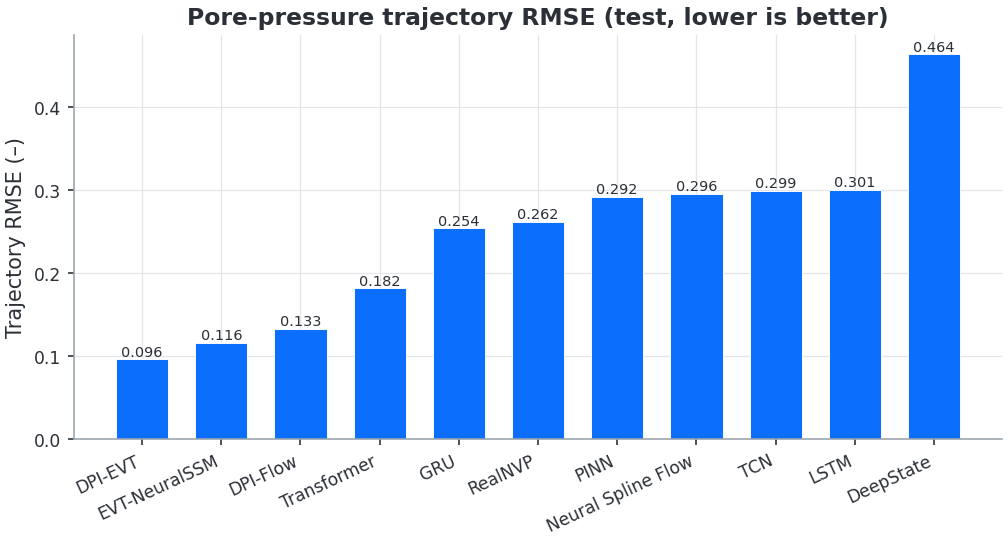

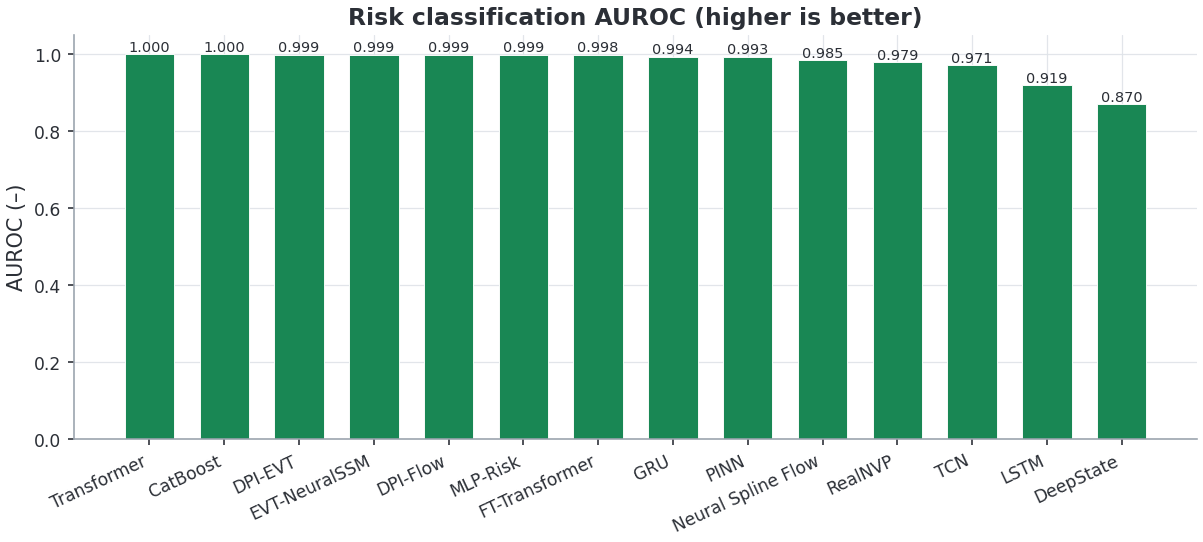

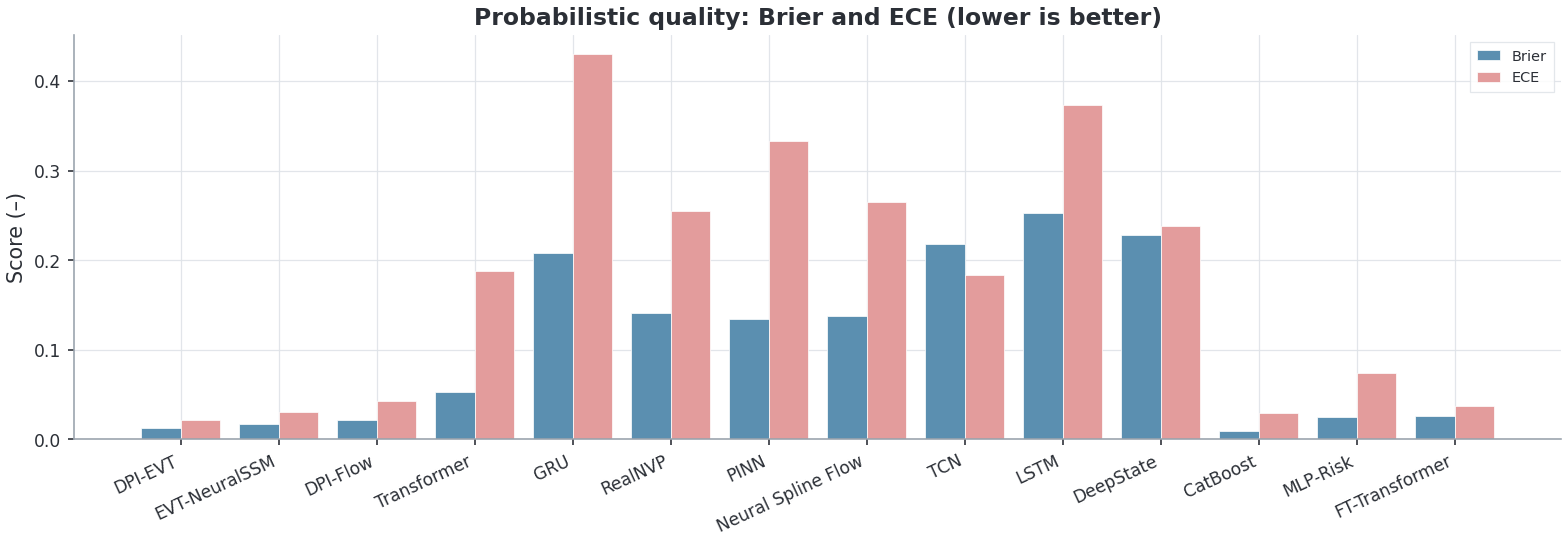

In [9]:
traj_df = leaderboard.dropna(subset=["Traj_RMSE"]).sort_values("Traj_RMSE")
bar(traj_df["model"], traj_df["Traj_RMSE"], title="Pore-pressure trajectory RMSE (test, lower is better)",
    ylabel="Trajectory RMSE (–)", color="#0b6efd", save=SAVE_FIGS, fig_id="3_1_leaderboard_rmse").show()
auc_df = leaderboard.sort_values("AUROC", ascending=False)
bar(auc_df["model"], auc_df["AUROC"], title="Risk classification AUROC (higher is better)",
    ylabel="AUROC (–)", color="#198754", save=SAVE_FIGS, fig_id="3_1_auroc").show()
grouped_bar(leaderboard["model"].tolist(),
            {"Brier": leaderboard["Brier"].tolist(), "ECE": leaderboard["ECE"].tolist()},
            title="Probabilistic quality: Brier and ECE (lower is better)", ylabel="Score (–)",
            save=SAVE_FIGS, fig_id="3_1_brier_ece").show()

## ROC curves

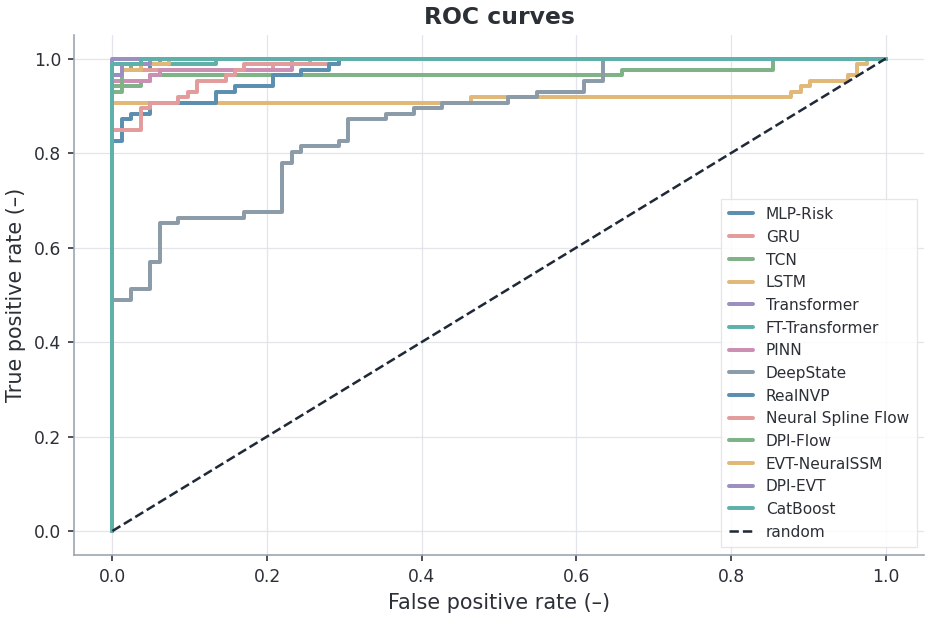

In [10]:
y_true = test["label"].cpu().numpy()
series = []
for disp, out in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, out["risk_prob"])
    series.append({"x": fpr, "y": tpr, "name": disp})
series.append({"x": [0, 1], "y": [0, 1], "name": "random", "color": "#1f2937", "dash": "dash", "width": 1.4})
lines(series, title="ROC curves", xlabel="False positive rate (–)", ylabel="True positive rate (–)",
      save=SAVE_FIGS, fig_id="3_1_roc_curves").show()

## Risk calibration

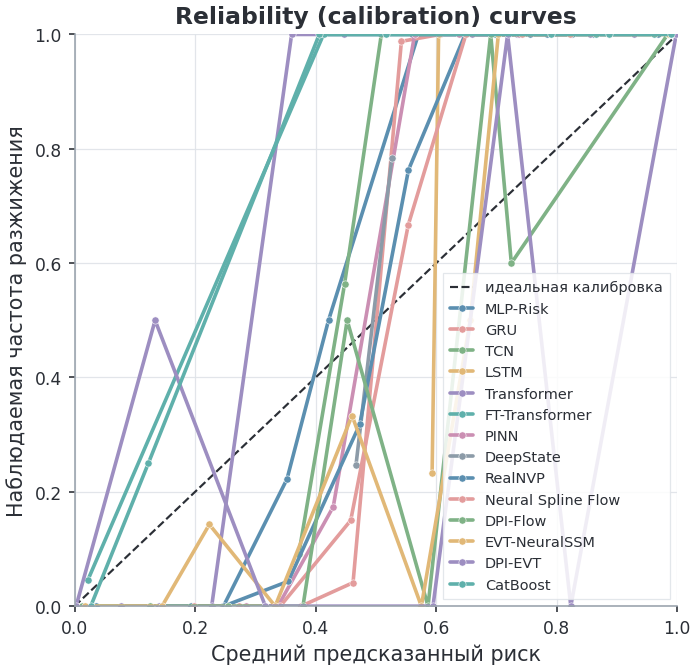

In [11]:
curves = {}
for disp in sample_tables:
    st = sample_tables[disp]
    if st["liq_label"].nunique() > 1:
        frac_pos, mean_pred = calibration_curve(st["liq_label"], st["risk_prob_pred"], n_bins=10)
        curves[disp] = (mean_pred, frac_pos)
calibration_plot(curves, title="Reliability (calibration) curves",
                 save=SAVE_FIGS, fig_id="3_1_calibration").show()

## Post-hoc temperature scaling

A single temperature T is fitted on the validation set per model and applied to the test
risk logits. This is a fair, universal post-hoc calibration step — it improves Brier/ECE
without changing AUROC (ranking is preserved).

,Model,T,Brier raw,Brier cal,ECE raw,ECE cal
0,MLP-Risk,1.08,0.0251,0.0270,0.0740,0.0822
1,GRU,0.15,0.2075,0.0804,0.4301,0.2270
2,TCN,0.64,0.2179,0.2059,0.1835,0.3981
3,LSTM,0.45,0.2527,0.2797,0.3728,0.1955
4,Transformer,1.33,0.0523,0.0707,0.1879,0.2321
5,FT-Transformer,1.08,0.0255,0.0256,0.0374,0.0386
6,PINN,0.52,0.1348,0.0802,0.3328,0.2296
7,DeepState,1.00,0.2283,0.2283,0.2381,0.2381
8,RealNVP,0.05,0.1405,0.0740,0.2549,0.0685
9,Neural Spline Flow,0.05,0.1380,0.0721,0.2650,0.0725


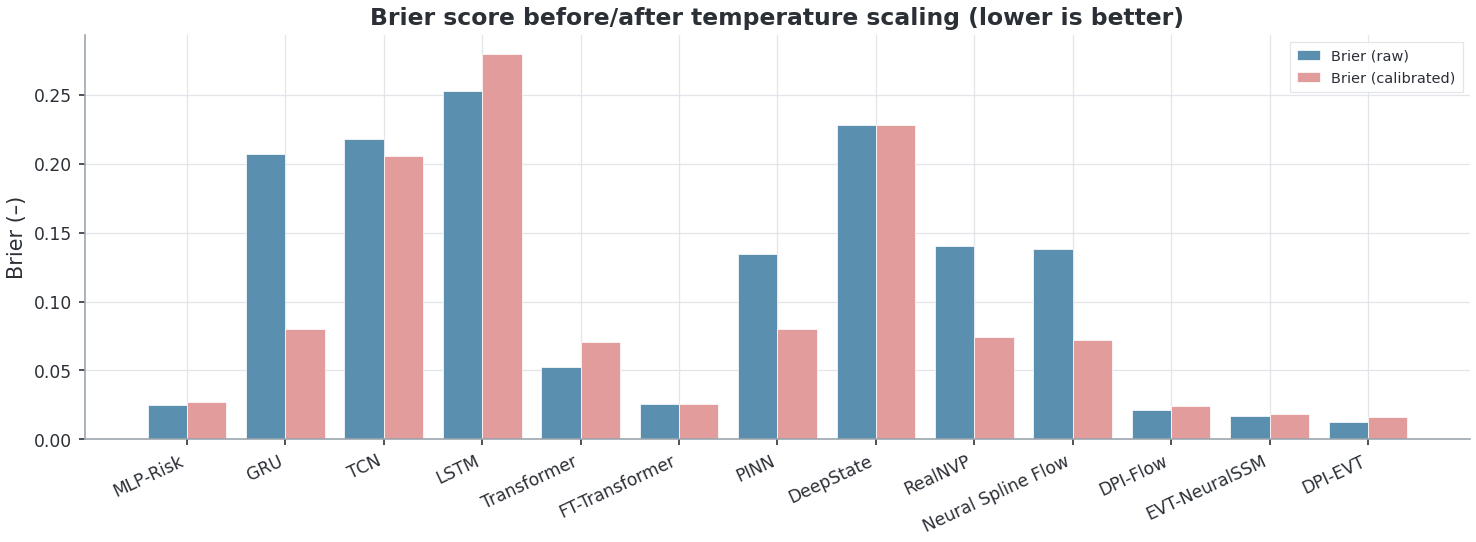

In [12]:
from liquefaction_ai.evaluation import fit_temperature, apply_temperature, expected_calibration_error, safe_binary_metrics

val = benchmark["val"]; y_val = val["label"].cpu().numpy(); y_test = test["label"].cpu().numpy()
cal_rows = []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name); disp = hp["display_name"]
    val_out = collect_outputs(model, val, config, device)
    vp = np.clip(val_out["risk_prob"], 1e-6, 1 - 1e-6); v_logit = np.log(vp / (1 - vp))
    T = fit_temperature(v_logit, y_val); T = float(np.clip(T if np.isfinite(T) else 1.0, 0.05, 20.0))
    p_raw = np.clip(np.nan_to_num(predictions[disp]["risk_prob"], nan=0.5), 1e-6, 1 - 1e-6)
    p_cal = np.clip(np.nan_to_num(apply_temperature(p_raw, T), nan=0.5), 1e-6, 1 - 1e-6)
    _, _, brier_raw = safe_binary_metrics(y_test, p_raw); ece_raw = expected_calibration_error(y_test, p_raw)
    _, _, brier_cal = safe_binary_metrics(y_test, p_cal); ece_cal = expected_calibration_error(y_test, p_cal)
    cal_rows.append({"Model": disp, "T": round(T, 2), "Brier raw": round(brier_raw, 4), "Brier cal": round(brier_cal, 4),
                     "ECE raw": round(ece_raw, 4), "ECE cal": round(ece_cal, 4)})
cal_df = pd.DataFrame(cal_rows)
display(cal_df)
grouped_bar(cal_df["Model"].tolist(), {"Brier (raw)": cal_df["Brier raw"].tolist(), "Brier (calibrated)": cal_df["Brier cal"].tolist()},
            title="Brier score before/after temperature scaling (lower is better)", ylabel="Brier (–)",
            save=SAVE_FIGS, fig_id="3_1_temperature_scaling").show()

## Uncertainty: coverage and interval width

,Model,Coverage@90%,Interval width@90%
0,DPI-EVT,0.9401,0.3311
1,EVT-NeuralSSM,0.9605,0.4414
2,DPI-Flow,0.9522,0.4348
3,Transformer,0.9573,0.6539
4,GRU,0.8457,0.7235
5,RealNVP,0.9271,0.7874
6,PINN,0.7803,0.8330
7,Neural Spline Flow,0.7172,0.7270
8,TCN,0.9980,1.3544
9,LSTM,0.9468,1.1660


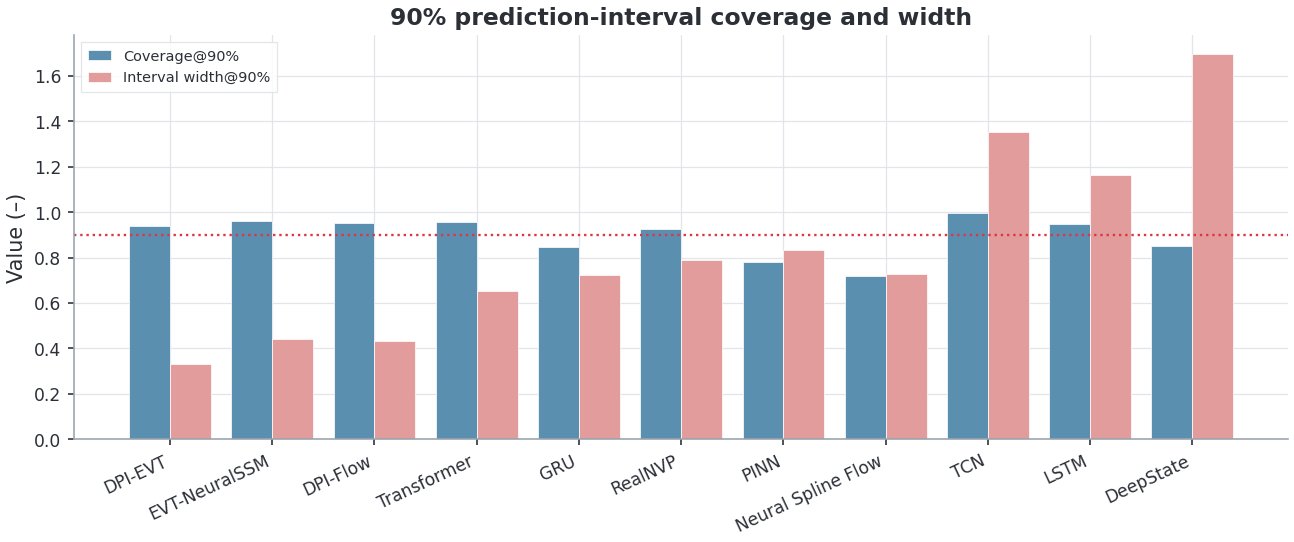

In [13]:
cov_df = leaderboard.dropna(subset=["Coverage_90"])[["model", "Coverage_90", "Interval_Width_90"]]
display(english_metric_table(cov_df).round(4))
fig = grouped_bar(cov_df["model"].tolist(),
                  {"Coverage@90%": cov_df["Coverage_90"].tolist(),
                   "Interval width@90%": cov_df["Interval_Width_90"].tolist()},
                  title="90% prediction-interval coverage and width", ylabel="Value (–)",
                  save=False, fig_id="3_1_coverage")
fig.add_hline(y=0.90, line_dash="dot", line_color="#dc3545")
from liquefaction_ai.viz import save_figure
save_figure(fig, "3_1_coverage", save=SAVE_FIGS)
fig.show()

## Итог

Структурированные модели дают CRR-границу, нулевые нарушения монотонности и осмысленную неопределённость; конкретные лидеры по CRPS, Brier, N_liq и CRR берутся из сохранённых таблиц этого ноутбука.
Дальше — **3.2 абляции и OOD**.
